# Lựa chọn Mô hình Học máy (Model Selection)

Notebook này thiết lập một Pipeline **Spot-Checking** đa mô hình để tìm ra thuật toán ưu việt nhất cho bài toán chẩn đoán ung thư da dạng bảng (Tabular Data).
- Cuộc đua của 8 mô hình: *Logistic Regression, KNN, SVC, Decision Tree, Random Forest, Extra Trees, XGBoost, LightGBM*.
- So găng trên 2 bộ dữ liệu: Trước và Sau khi Lựa chọn Đặc trưng (Feature Selection).
- Đánh giá bằng: *Macro F1-Score, ROC-AUC, Recall* với hệ thống kiểm định chéo Stratified 5-Fold Cross Validation trên tập Train.
- Trực quan hoá Confusion Matrix trên nhãn dự đoán của tập Test Hold-out.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid")

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
import xgboost as xgb
import lightgbm as lgb

# Scale & Metric & Validation
from sklearn.model_selection import StratifiedKFold, cross_validate
from sklearn.metrics import f1_score, roc_auc_score, recall_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelBinarizer

## 1. Tải 2 phiên bản Dữ liệu

In [9]:
data_dir = '../Data_handle/data/'

# Nhãn phân loại
y_train = pd.read_csv(data_dir + 'y_train.csv')
y_test = pd.read_csv(data_dir + 'y_test.csv')

# Dữ liệu TRƯỚC Feature Selection
X_train_v1 = pd.read_csv(data_dir + 'X_train_before_selection.csv')
X_test_v1 = pd.read_csv(data_dir + 'X_test_before_selection.csv')

# Dữ liệu SAU Feature Selection
X_train_v2 = pd.read_csv(data_dir + 'X_train_after_selection.csv')
X_test_v2 = pd.read_csv(data_dir + 'X_test_after_selection.csv')

# In log kiểm tra
print(f"Version 1 (All Features) - Train: {X_train_v1.shape}, Test: {X_test_v1.shape}")
print(f"Version 2 (Selected Features) - Train: {X_train_v2.shape}, Test: {X_test_v2.shape}")

Version 1 (All Features) - Train: (3930, 58), Test: (461, 58)
Version 2 (Selected Features) - Train: (3930, 20), Test: (461, 20)


## 2. Thiết lập Hàm Spot-Check
Hàm này sẽ nhận đầu vào là X_train và X_test. Sau đó tự động duyệt qua 8 Models, vừa tính điểm K-Fold để xếp hạng chống overfit, vừa tự động Fit & Predict trên Test để bung đồ thị Confusion Matrix.

In [10]:
# Multi-class ROC AUC require label binarization
lb = LabelBinarizer()
lb.fit(y_train)

def spot_check_models(X_train, X_test, y_train, y_test, dataset_name):
    models = {
        'Logistic Reg': LogisticRegression(max_iter=1000, random_state=42),
        'KNN': KNeighborsClassifier(),
        'SVC': SVC(probability=True, random_state=42),
        'Decision Tree': DecisionTreeClassifier(random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'Extra Trees': ExtraTreesClassifier(n_estimators=100, random_state=42),
        'XGBoost': xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42),
        'LightGBM': lgb.LGBMClassifier(random_state=42, verbose=-1)
    }
    
    results = []
    # Bố cục 3 cột cho đồ thị
    n_models = len(models)
    n_cols = 3
    n_rows = math.ceil(n_models / n_cols)
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
    axes = axes.flatten()
    
    print(f"--- Đang tiến hành chạy Spot-Check trên tập {dataset_name} ---")
    for idx, (name, base_model) in enumerate(models.items()):
        # Gói scaler cho các mô hình khoảng cách
        if name in ['Logistic Reg', 'KNN', 'SVC']:
            model = make_pipeline(StandardScaler(), base_model)
        else:
            model = base_model
            
        # 1. K-Fold CV
        skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_scores = cross_validate(model, X_train, y_train.values.ravel(), cv=skf, 
                                   scoring=('f1_macro', 'recall_macro'), n_jobs=-1)
        
        f1_cv = cv_scores['test_f1_macro'].mean()
        recall_cv = cv_scores['test_recall_macro'].mean()
        
        # 2. Predict on Test set để ra ma trận tóm tắt
        model.fit(X_train, y_train.values.ravel())
        y_pred = model.predict(X_test)
        
        # 3. Store Results
        results.append({
            'Dataset': dataset_name,
            'Model': name,
            'CV_Macro_F1': f1_cv,
            'CV_Recall': recall_cv
        })
        
        # 4. Vẽ Confusion Matrix
        cm = confusion_matrix(y_test, y_pred)
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=lb.classes_)
        disp.plot(ax=axes[idx], cmap='Blues', colorbar=False, values_format='d')
        axes[idx].set_title(f"{name} (CV F1: {f1_cv:.3f})")
        axes[idx].grid(False) # Tắt grid đè lên matrix
        
    # Ẩn các trục ô dư
    for i in range(n_models, len(axes)):
        fig.delaxes(axes[i])
        
    plt.tight_layout()
    plt.suptitle(f'Confusion Matrices trên tập Hold-out Test ({dataset_name})', y=1.02, fontsize=16)
    plt.show()
    
    df_res = pd.DataFrame(results)
    return df_res.sort_values(by='CV_Macro_F1', ascending=False)


## 3. Khởi chạy Chiến dịch trên Tập Full Đặc trưng (V1)

--- Đang tiến hành chạy Spot-Check trên tập V1_All_Features ---


/Users/hhh/workspace/school/PBL7/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:04:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/hhh/workspace/school/PBL7/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:04:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/hhh/workspace/school/PBL7/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:04:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/hhh/workspace/school/PBL7/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:04:28] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } ar

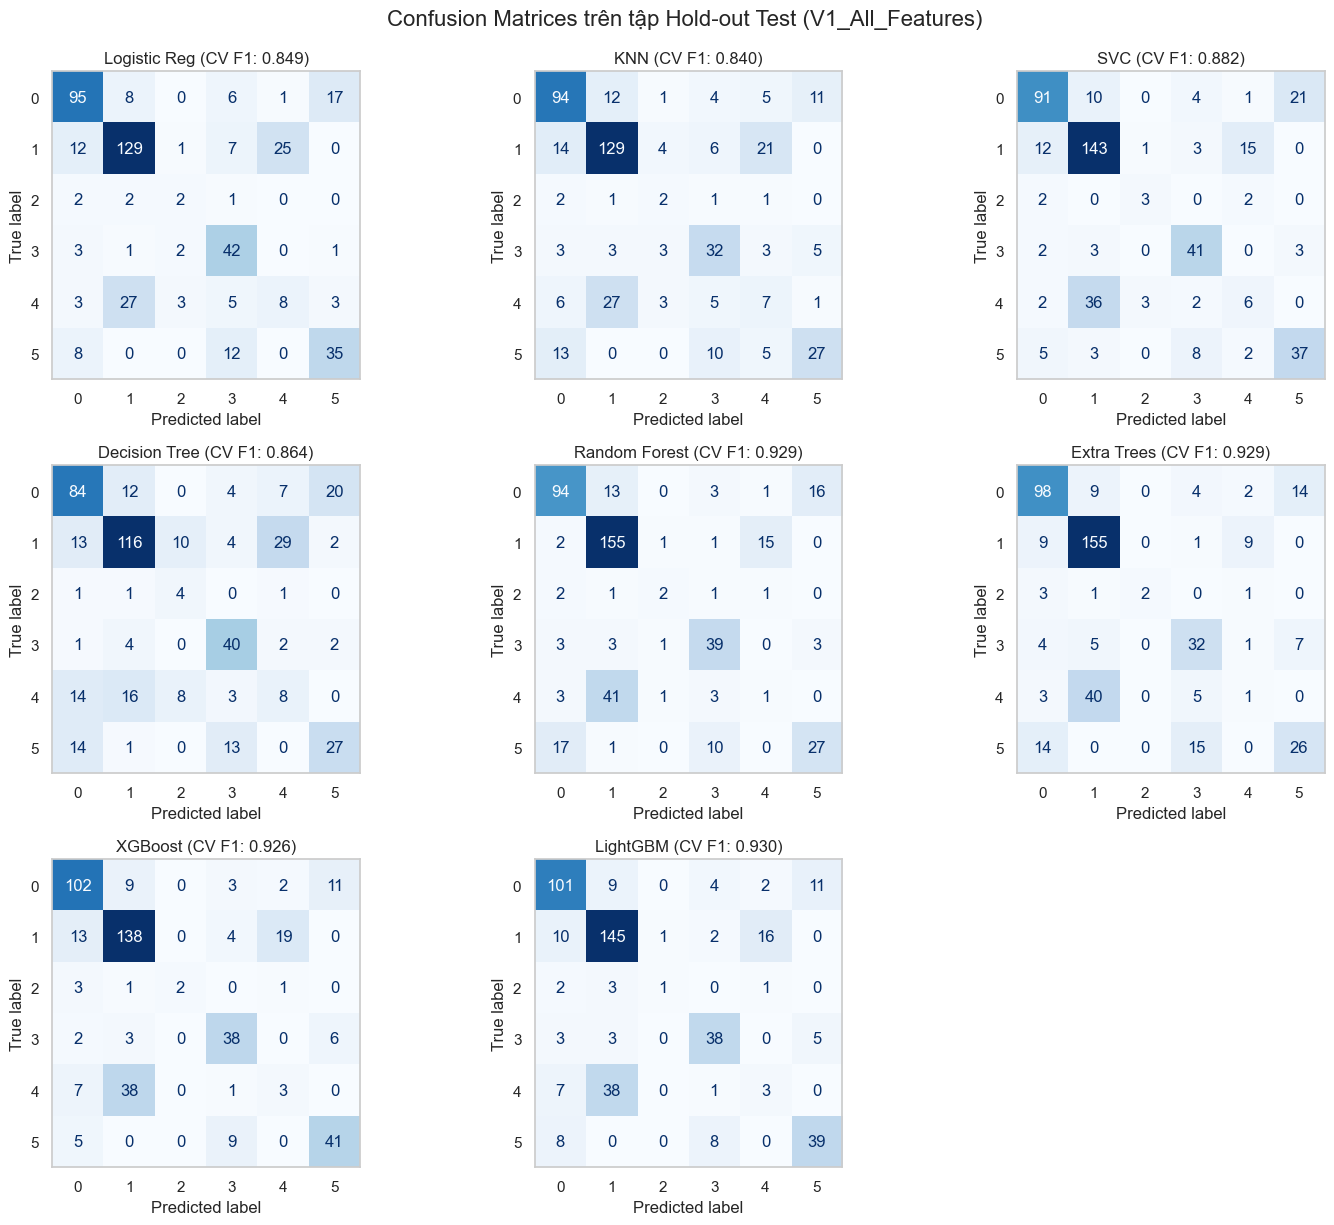

,Dataset,Model,CV_Macro_F1,CV_Recall
7,V1_All_Features,LightGBM,0.929985,0.930315
5,V1_All_Features,Extra Trees,0.929188,0.929307
4,V1_All_Features,Random Forest,0.929083,0.929430
6,V1_All_Features,XGBoost,0.925889,0.926102
2,V1_All_Features,SVC,0.881588,0.882283
3,V1_All_Features,Decision Tree,0.864187,0.864481
0,V1_All_Features,Logistic Reg,0.848836,0.849066
1,V1_All_Features,KNN,0.840330,0.841397


In [11]:
res_v1 = spot_check_models(X_train_v1, X_test_v1, y_train, y_test, 'V1_All_Features')
display(res_v1)

## 4. Khởi chạy Chiến dịch trên Tập Đặc trưng Đã Cắt Tỉa (V2)

--- Đang tiến hành chạy Spot-Check trên tập V2_Short_Features ---


/Users/hhh/workspace/school/PBL7/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:04:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/hhh/workspace/school/PBL7/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:04:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/hhh/workspace/school/PBL7/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:04:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/Users/hhh/workspace/school/PBL7/venv/lib/python3.9/site-packages/xgboost/core.py:158: UserWarning: [18:04:43] WARNING: /Users/runner/work/xgboost/xgboost/src/learner.cc:740: 
Parameters: { "use_label_encoder" } ar

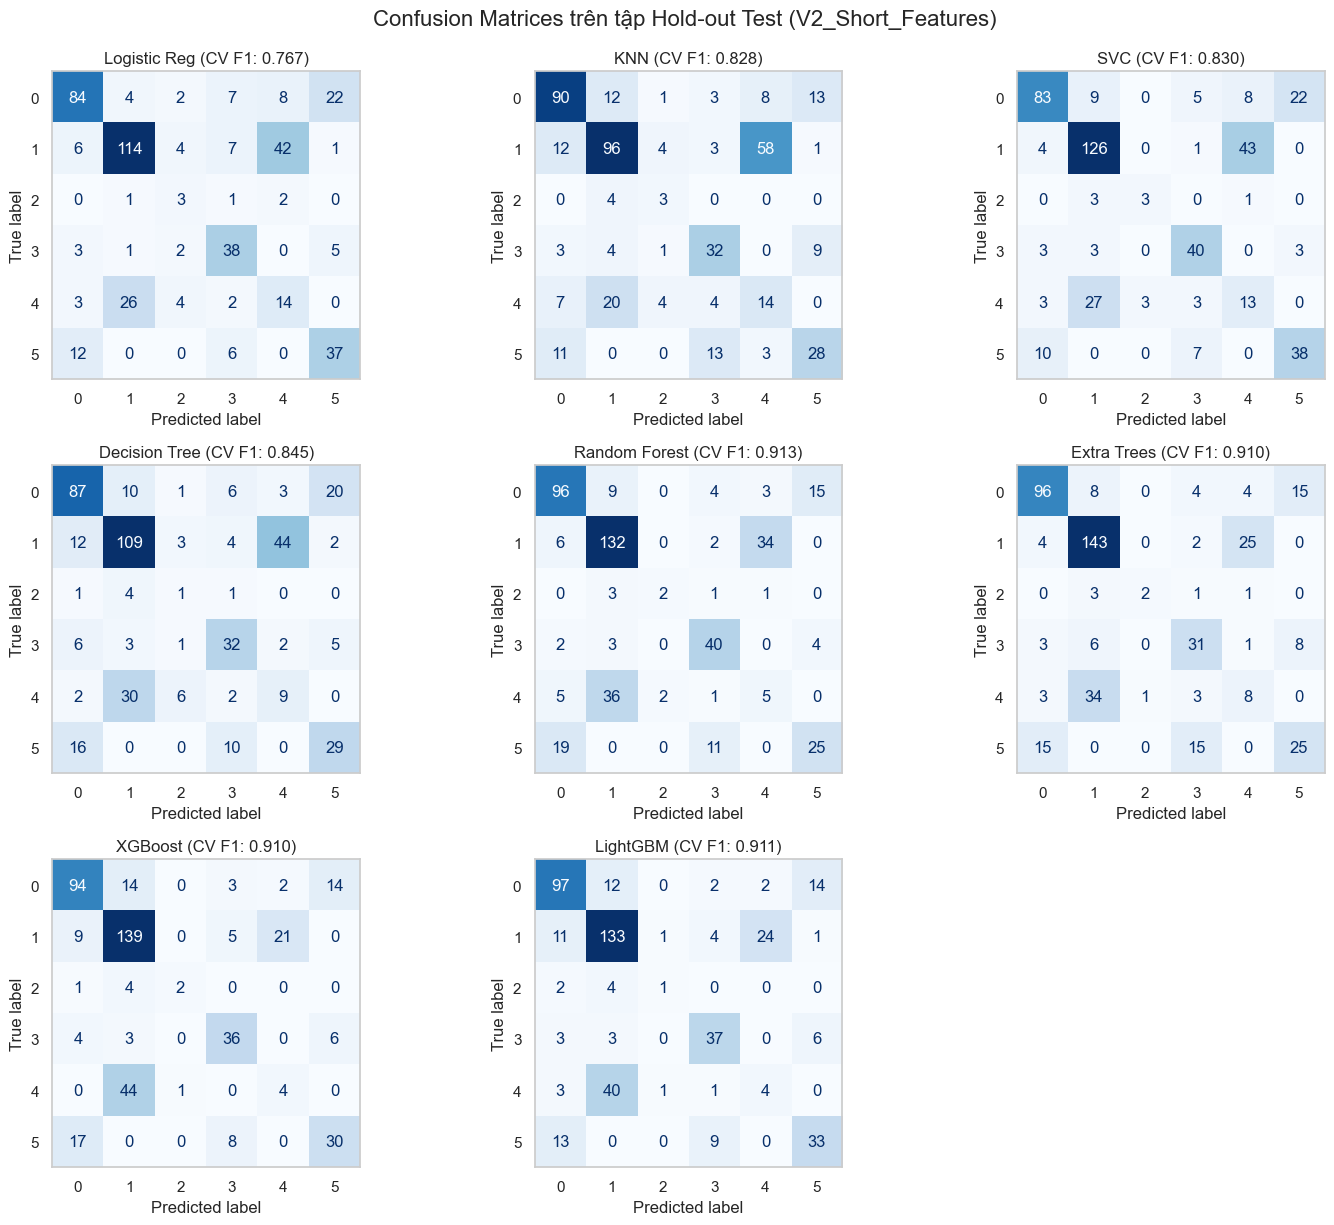

,Dataset,Model,CV_Macro_F1,CV_Recall
4,V2_Short_Features,Random Forest,0.913429,0.914020
7,V2_Short_Features,LightGBM,0.910785,0.911118
5,V2_Short_Features,Extra Trees,0.910307,0.910580
6,V2_Short_Features,XGBoost,0.909886,0.910241
3,V2_Short_Features,Decision Tree,0.845272,0.845979
2,V2_Short_Features,SVC,0.829898,0.831120
1,V2_Short_Features,KNN,0.827965,0.830204
0,V2_Short_Features,Logistic Reg,0.766859,0.768345


In [12]:
res_v2 = spot_check_models(X_train_v2, X_test_v2, y_train, y_test, 'V2_Short_Features')
display(res_v2)

## 5. Tổng kết so sánh & Đề xuất Mô hình Quán Quân
Gộp cả 2 bảng và vẽ Barplot biểu diễn hiệu suất F1-Score.

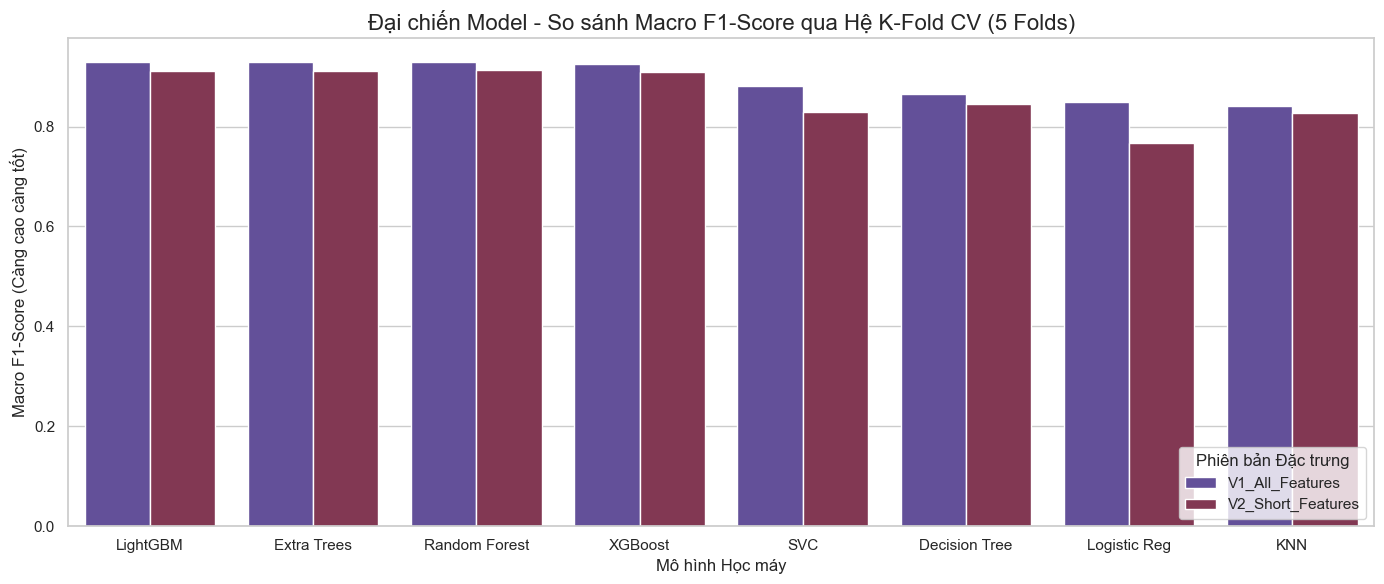

Bảng xếp hạng TỔNG SẮP (Top 5):


,Dataset,Model,CV_Macro_F1,CV_Recall
7,V1_All_Features,LightGBM,0.929985,0.930315
5,V1_All_Features,Extra Trees,0.929188,0.929307
4,V1_All_Features,Random Forest,0.929083,0.929430
6,V1_All_Features,XGBoost,0.925889,0.926102
4,V2_Short_Features,Random Forest,0.913429,0.914020


In [13]:
df_final = pd.concat([res_v1, res_v2], axis=0)

plt.figure(figsize=(14, 6))
sns.barplot(data=df_final, x='Model', y='CV_Macro_F1', hue='Dataset', palette='twilight')
plt.title('Đại chiến Model - So sánh Macro F1-Score qua Hệ K-Fold CV (5 Folds)', fontsize=16)
plt.ylabel('Macro F1-Score (Càng cao càng tốt)')
plt.xlabel('Mô hình Học máy')
plt.legend(title='Phiên bản Đặc trưng', loc='lower right')
plt.tight_layout()
plt.show()

print("Bảng xếp hạng TỔNG SẮP (Top 5):")
display(df_final.sort_values(by='CV_Macro_F1', ascending=False).head(5))